# Ariel MCS — Introduction for the RL Project

This notebook is for James, as a starting point for his RL project.

It introduces the **Ariel Mission Candidate Sample (MCS)** and the key quantities likely to matter for the agent's state/action space and reward design: planet and star properties, and the **observation time cost** of each target.

**Structure:**
1. Load the MCS target list
2. Time cost — what it is, how it's computed, and why it matters for scheduling
3. Filter out targets with prohibitively long time costs
4. Select and preprocess the physical features relevant to the agent
5. Quick exploratory look at the resulting feature distributions


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import RobustScaler

## 1. Load the MCS target list

In [2]:
data_path = '../target_list/Ariel_MCS_Known_2025-08-18.csv'
MCS_data = pd.read_csv(data_path)

## 2. Time cost

Each target's observation time cost is what determines how many targets can realistically be scheduled within the mission lifetime, so it's a natural quantity to expose to the agent (either as part of the state, or to constrain the action space).

**Formula:**

$$\text{Time cost} = \text{Tier Observations} \times \text{Transit Duration } T_{14}\,[s] \times 2.5$$

- **Transit Duration `T14`** is the time for one transit of the planet.
- **Tier Observations** is the number of transits required to reach the target's classification tier (Tier 1 or Tier 2 — higher tiers need more repeat observations for adequate SNR).
- The **2.5 factor** provides enough out-of-transit baseline on either side of the transit for the mission.

This assumes back-to-back scheduling with no gaps between transits, so it's a lower bound on the true cost, not a realistic schedule — useful for ranking targets, less useful as a literal duration.


In [11]:
mission_lifetime = 3.5 * 365.25 * 24 * 3600  # 3.5 year mission lifetime, in seconds, you might want it to be 5, 3.5 factor is to account for slewing time, but you have already account for it. 
one_year = 365.25 * 24 * 3600

In [4]:
# Total time cost per target, assuming no gaps between repeat transits
time_cost = (
    MCS_data['Transit Duration T14 [s]'] / 3600 / 24 / 365.25 * 2.5 * MCS_data['Tier 2 Observations']
)  # in years

# Time cost of a single transit (i.e. the per-observation building block above)
one_time_cost = MCS_data['Transit Duration T14 [s]'] / 3600 / 24 / 365.25 * 2.5  # in years

**Note for James:** the formula above assumes Tier 2 classification and zero scheduling gaps. A more realistic cost model would add gaps between transits and/or use whichever tier (1 or 2) is relevant to the target — worth revisiting once the scheduling environment is more concrete.

## 3. Filter out impractically long targets

Targets with a time cost above 10 days are dropped here as a simplifying assumption for the exploratory plots below — this isn't a hard scientific cutoff, just a convenience filter, so feel free to drop or loosen it depending on what the agent needs to see.


In [5]:
time_cost_days = time_cost * 365.25

filtered_time_cost = time_cost[time_cost_days < 10]
MCS_data = MCS_data[time_cost_days < 10].reset_index(drop=True)

**Fix applied:** the original filter recomputed the mask separately for `filtered_time_cost` and `MCS_data`, which works once but breaks (or silently misaligns) if the cell is rerun out of order, since `MCS_data` shrinks on each rerun while `time_cost` does not. The version above computes the mask once (`time_cost_days < 10`) and reuses it, and resets the index after filtering so it stays aligned with anything downstream.

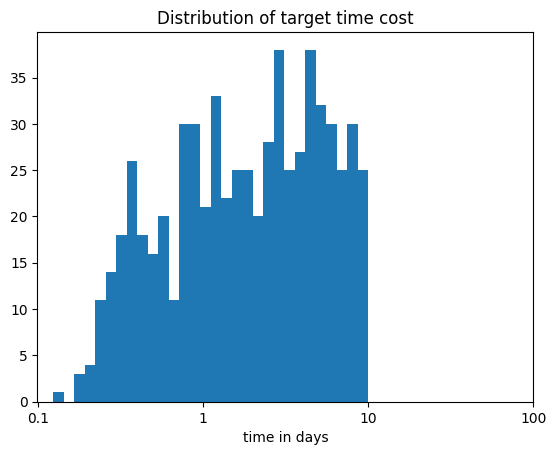

In [6]:
## Histogram of planets by time cost
plt.hist(np.log10(filtered_time_cost * 365.25), bins=30)
plt.xlabel('time in days')
xrange = [0.1, 1, 10, 100]
log_xrange = np.log10(xrange)
plt.xticks(log_xrange, xrange)
plt.title('Distribution of target time cost')
plt.show()

## 4. Select and preprocess features for the agent

In [7]:
selected_col = [
    'Planet Temperature [K]',
    'Planet Radius [Re]',
    'Planet Mass [Me]',
    'Star Temperature [K]',
    'Star Age [Gyr]',
    'Star Metallicity',
    'Planet Period [days]',
]

In [8]:
def preprocess(data, selected_col):
    selected_data = data[selected_col].copy()

    selected_data['Planet Mass [Me]'] = np.log10(selected_data['Planet Mass [Me]'])
    selected_data['Planet Radius [Re]'] = np.log10(selected_data['Planet Radius [Re]'])
    selected_data['Planet Period [days]'] = np.log10(selected_data['Planet Period [days]'])
    selected_data['Time Cost'] = data['Tier 2 Observations'] * data['Transit Duration T14 [s]'] * 2.5
    selected_data.dropna(inplace=True)

    return selected_data

**Fix applied:** added `.copy()` when selecting `selected_col` from `data`. Without it, `selected_data` is a view into `MCS_data`, and the column reassignments below it (`np.log10(...)` etc.) can throw a `SettingWithCopyWarning` or, depending on pandas version, silently fail to modify what you think they're modifying. `.copy()` makes `selected_data` fully independent.

In [9]:
selected_mcs_data = preprocess(MCS_data, selected_col)
selected_mcs_data.shape

(531, 8)

## 5. Quick look at the feature distributions

Planet radius, mass, and temperature (along with the other selected features) for the filtered MCS sample.


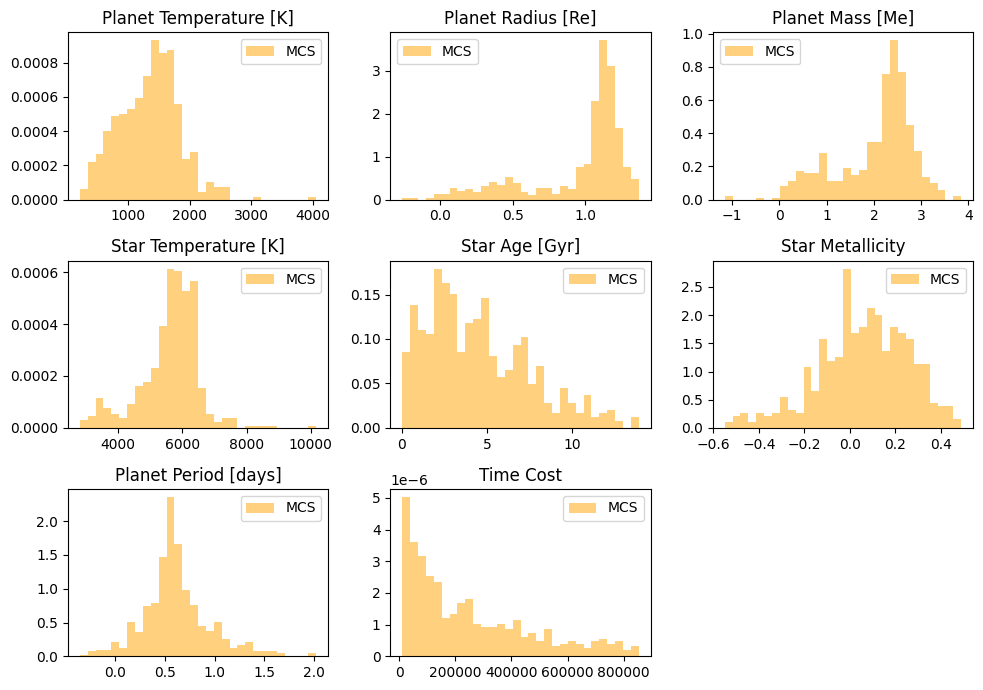

In [10]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(10, 7))
ax = ax.flatten()

for idx, col in enumerate(selected_mcs_data):
    ax[idx].set_title(col)
    ax[idx].hist(selected_mcs_data[col], bins=30, label='MCS', density=True, alpha=0.5, color='orange')
    ax[idx].legend()

# Hide any unused subplot axes (9 slots for 8 columns, for example)
for j in range(idx + 1, len(ax)):
    ax[j].axis('off')

plt.tight_layout()
plt.show()

**Fix applied:** the original cell referenced `bins1`, which was never defined anywhere in the notebook (it looks like a leftover from an earlier version that captured histogram output) — this cell would have thrown a `NameError` and stopped James cold. It now computes its own bins per-feature. Also added a loop to turn off any unused subplot axes, since `selected_mcs_data` may have fewer than 9 columns depending on what's selected above.

## Next steps for James

A few natural extensions from here, in case useful for the RL setup:

- The 10-day filter above is arbitrary — consider whether the agent should see the full distribution (including long-cost targets) so it can learn to deprioritize them itself.
- `mission_lifetime` is defined but unused so far — likely needed once you get to defining episode length / budget exhaustion.
